In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.special import softmax
from statannotations.Annotator import Annotator
from scipy.stats import ttest_rel
from matplotlib.ticker import MultipleLocator

sns.set_style("whitegrid")
plt.rcParams.update({
    "xtick.bottom": True,
    "axes.edgecolor": "black"
})

custom_thresholds = [
    # [0.0001, '****'],  # p <= 0.0001 gets 4 stars
    [0.001,  '***'],   # 0.0001 < p <= 0.001 gets 3 stars
    [0.01,   '**'],    # 0.001 < p <= 0.01 gets 2 stars
    [0.05,   '*'],     # 0.01 < p <= 0.05 gets 1 star
    [1,      'ns']     # p > 0.05 gets 'ns' (not significant)
]

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='repeated', ylabel='optimal'>

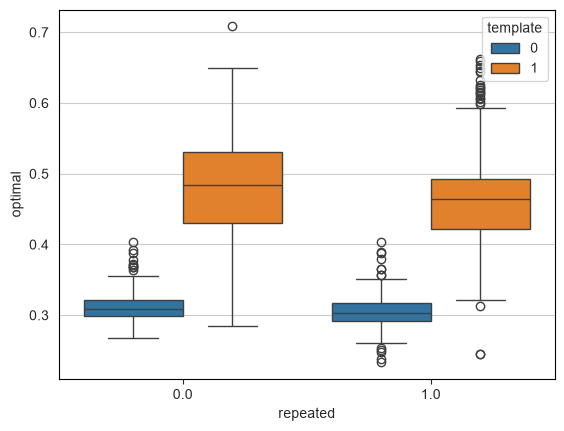

In [25]:
# df = pd.read_csv('test.csv')
df["optimal"] = df["choice"] == df["phase"]
df2 = df.query("block <= 7").groupby(by=["template","agent","repeated"])["optimal"].mean().reset_index()
sns.boxplot(data=df2, y="optimal", x="repeated",hue="template")
# df2.head()

In [18]:
df.agent

0            0
1            0
2            0
3            0
4            0
          ... 
1439995    399
1439996    399
1439997    399
1439998    399
1439999    399
Name: agent, Length: 1440000, dtype: int64

In [2]:
def simulate_MFRL(alpha, epsilon, dec_temps, training_regime, trials_per_context, n_sims, n_trials, reward_contingencies,reps):
	Q_action = np.ones([n_sims, n_trials+1,nb])*0.5   # action values
	P_action = np.zeros([n_sims, n_trials+1,nb])      # action probabilities
	P_action[:,0,:] = 1/nb

	rewards = np.zeros([n_sims, n_trials])
	actions = np.zeros([n_sims, n_trials])

	dfs = []
	# run sims
	for dec_temp in dec_temps:
		for agent in range(n_sims):
			for t in range(n_trials):

				# e-greedy action selection, if not argmax choice than any other one with equal probability
				# if np.random.uniform() < epsilon:
				#     all_actions = np.arange(nb) 
				#     all_actions = all_actions[all_actions != np.argmax(P_action[agent,t])]
				#     # Q_reduced = Q_action[agent,t,all_actions]'
				#     # P_reduced = softmax(Q_reduced)
				#     # action = np.random.choice(nb-1, p=P_reduced)
				#     np.random.shuffle(all_actions)
				#     action = all_actions[0]
				#     print(agent,t,"greedy action",action)
				# else:
				#     action = np.argmax(P_action[agent,t])
				action = np.random.choice(nb, p=P_action[agent,t])
				context = training_regime[t]
				reward = np.random.choice(nr, p=reward_contingencies[:,action,context])
				
				rewards[agent,t] = reward
				actions[agent,t] = action

				Q_action[agent,t+1] = Q_action[agent,t] + alpha*(reward - Q_action[agent,t])*np.eye(nb)[action]
				P_action[agent,t+1] = softmax(dec_temp*Q_action[agent,t+1])

				assert np.isclose(P_action[agent,t+1].sum(),1)

			df_dict = {
				"agent" : np.array([agent]).repeat(n_trials),
				"context": np.tile(np.arange(nc).repeat(trials_per_context),reps),
				"trial" : np.arange(n_trials),
				"actions" : actions[agent],
				"reward" : rewards[agent],
				"dec_temp": np.array([dec_temp]*n_trials),
				"repeated": np.arange(reps).repeat(n_trials//reps)
			}

			for bandit in range(nb):
				df_dict[f"q_{bandit}"] = Q_action[agent,:-1,bandit]#.reshape(n_sims*n_trials)
			for bandit in range(nb):
				df_dict[f"p_{bandit}"] = P_action[agent,:-1,bandit]#.reshape(n_sims*n_trials)

			# for key,val in df_dict.items():
			# 	print(key, val.size)
			dfs.append(pd.DataFrame(df_dict))

	df = pd.concat(dfs)
	return df

### Simulate and analyse 3 armed bandit

In [1]:
nb = 4
nr = 2
nc = 3

trials_per_context = 300
reps = 2
training_regime = np.tile(np.arange(nc).repeat(trials_per_context),reps)
n_trials = training_regime.size
n_sims = 200
dec_temps  = [2]

# bandit reward contingencies
p = 0.9
p_reward = np.ones([nb,nb])*(1-p) + np.eye(nb)*(p-1+p)
p_no_reward = np.ones([nb,nb])*p - np.eye(nb)*(p-1+p)
reward_contingencies = np.stack([p_no_reward, p_reward],axis=0)
# print(reward_contingencies[:,:,0])

alpha = 0.2                                       # learning rate
epsilon = 0.1                                     # e-greedy decision rule

df = simulate_MFRL(alpha, epsilon, dec_temps, training_regime, trials_per_context, n_sims, n_trials, reward_contingencies,reps)
sns.set_style("whitegrid")

plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"q_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$\mathbb{E}_{r|a}$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))
g.xaxis.set_major_locator(MultipleLocator(130))
plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"p_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$p(a)$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))
g.xaxis.set_major_locator(MultipleLocator(130))


plt.figure()
df["optimal"] = df["context"] == df["actions"]
g = sns.boxplot(data=df.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index(), y="optimal", x="dec_temp", hue="repeated",palette="Greys_r")
g.set_ylim([0,1])

# df_test = df.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index().set_index(["dec_temp","agent","repeated"])+
# df_test.to_csv("mfrl_data.csv")
# ttest_rel(df_test.loc[1,:,0],df_test.loc[1,:,1])
# ttest_rel(df_test.loc[3,:,0],df_test.loc[3,:,1])

NameError: name 'np' is not defined

In [ ]:
df_big = df.copy().query("context>0")
df_big["optimal"] = df_big["context"] == df_big["actions"]
g = sns.boxplot(data=df_big.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index(), y="optimal", x="dec_temp", hue="repeated",palette="Greys_r")
g.set_ylim([0,1])



unique_models = sorted(df["dec_temp"].unique())
box_pairs = [((model, 0), (model, 1)) for model in unique_models]
# Create the annotator
annotator = Annotator(g, pairs=box_pairs, data=df, x="dec_temp", y="optimal", hue="repeated")
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", comparisons_correction=None, verbose=0)
test,results = annotator.apply_and_annotate()

#################################

df_big = df.copy()
plt.figure()
df_big["optimal"] = df_big["context"] == df_big["actions"]
g = sns.boxplot(data=df_big.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index(), y="optimal", x="dec_temp", hue="repeated",palette="Greys_r")
g.set_ylim([0,1])

unique_models = sorted(df["dec_temp"].unique())
box_pairs = [((model, 0), (model, 1)) for model in unique_models]
# Create the annotator
annotator = Annotator(g, pairs=box_pairs, data=df, x="dec_temp", y="optimal", hue="repeated")
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", comparisons_correction=None, verbose=0)
test,results = annotator.apply_and_annotate()

for res in results:
	print(res.data)

['MFRL', 'NP-BCC']
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

NP-BCC_0 vs. NP-BCC_1: Mann-Whitney-Wilcoxon test two-sided, P_val:2.075e-07 U_stat=1.400e+04
MFRL_0 vs. MFRL_1: Mann-Whitney-Wilcoxon test two-sided, P_val:9.125e-01 U_stat=2.013e+04
Mann-Whitney-Wilcoxon test two-sided, P_val:2.075e-07 U_stat=1.400e+04
Mann-Whitney-Wilcoxon test two-sided, P_val:9.125e-01 U_stat=2.013e+04


C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\3226876317.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.yaxis.get_ticklabels(), fontsize=12)
C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\3226876317.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive"], fontsize=14)


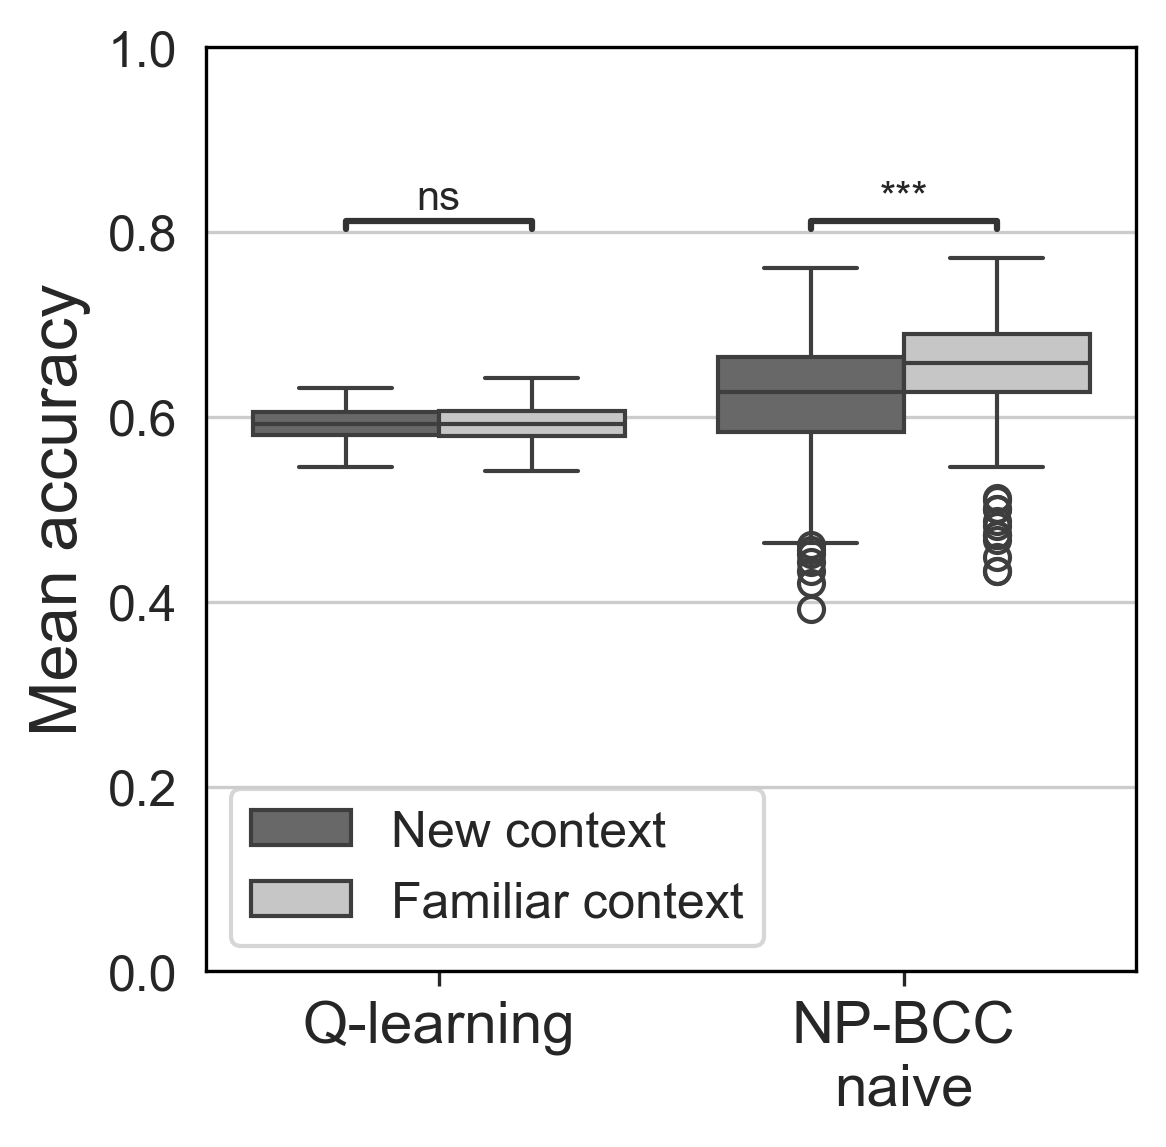

In [66]:
mf = pd.read_csv("mfrl_data.csv")
mf["model"] = "MFRL"
bcc = pd.read_csv("bcc_data.csv")
df_new = pd.concat([mf.query("dec_temp == 2"),bcc])

fig, ax = plt.subplots(1,1,figsize=(4,4),dpi=300)
g = sns.boxplot(ax=ax, data=df_new, x="model", y="optimal",palette="Greys_r", hue="repeated")
df_new["model"].unique()
unique_models = sorted(df_new["model"].unique())
print(unique_models)
box_pairs = [((model, 0), (model, 1)) for model in unique_models]
# box_pairs = [((0,0),(1,0)),((0,1),(1,1))]
# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df_new, x="model", y="optimal",hue="repeated")
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", comparisons_correction=None, verbose=2, pvalue_thresholds=custom_thresholds)
test,results = annotator.apply_and_annotate()       

ax.set_ylim([0,1])
ax.set_ylabel("Mean accuracy", fontsize=16)
ax.set_yticklabels(ax.yaxis.get_ticklabels(), fontsize=12)
handles, labels = g.get_legend_handles_labels()
ax.legend(handles=handles,labels=["New context","Familiar context"],fontsize=12)
ax.set_xlabel("")
ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive"], fontsize=14)

for res in results:
	print(res.data)
	
fig.savefig("supp_fig_1.svg")

['MFRL', 'NP-BCC']
Mann-Whitney-Wilcoxon test two-sided, P_val:3.563e-35 U_stat=5.694e+03
Mann-Whitney-Wilcoxon test two-sided, P_val:3.490e-06 U_stat=1.464e+04
Mann-Whitney-Wilcoxon test two-sided, P_val:3.925e-05 U_stat=2.475e+04
Mann-Whitney-Wilcoxon test two-sided, P_val:2.075e-07 U_stat=1.400e+04


C:\Users\siahr\AppData\Local\Temp\ipykernel_20760\497042916.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["New\nContext","Familiar\nContext"], fontsize=14)


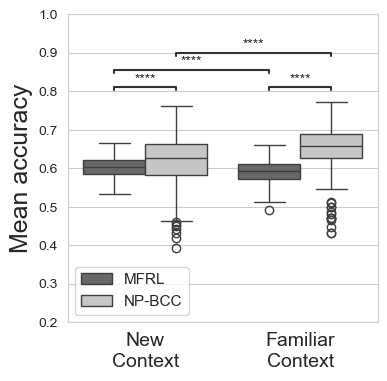

In [ ]:
mf = pd.read_csv("mfrl_data.csv")
bcc = pd.read_csv("bcc_data.csv")
df_new = pd.concat([mf.query("dec_temp == 2"),bcc])

fig, ax = plt.subplots(1,1,figsize=(4,4),dpi=100)
g = sns.boxplot(ax=ax, data=df_new, x="repeated", y="optimal", hue="model",palette="Greys_r")

unique_models = sorted(df_new["model"].unique())
print(unique_models)
# box_pairs = [((0, model), (1, model)) for model in unique_models]
box_pairs = [((0,unique_models[0]),(0,unique_models[1])),((1,unique_models[0]),(1,unique_models[1])),\
			 ((0,unique_models[0]),(1,unique_models[0])),((0,unique_models[1]),(1,unique_models[1]))]
# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df_new, x="repeated", y="optimal", hue="model")
annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", comparisons_correction=None, verbose=0)
test,results = annotator.apply_and_annotate()       

ax.set_ylim([0.2,1])
ax.set_ylabel("Mean accuracy", fontsize=18)
handles, labels = g.get_legend_handles_labels()
ax.legend(handles=handles,labels=["Q-learning","NP-BCC"],fontsize=11,loc="lower left")
ax.set_xlabel("")
ax.set_xticklabels(labels=["New\nContext","Familiar\nContext"], fontsize=14)

for res in results:
	print(res.data)
	
# fig.savefig("supp_fig_1.png")

### Simulate 4-armed bandit (habit)

(0.0, 1.0)

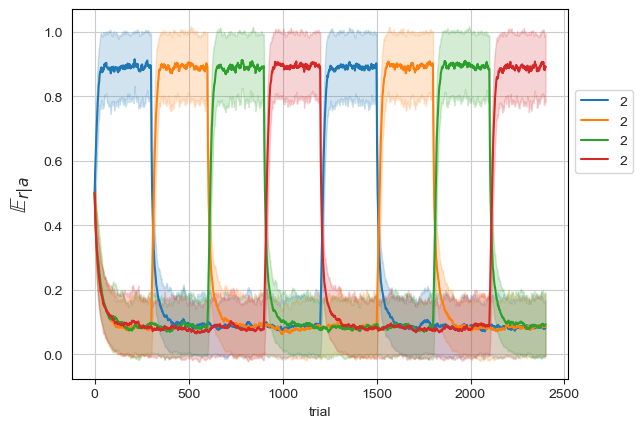

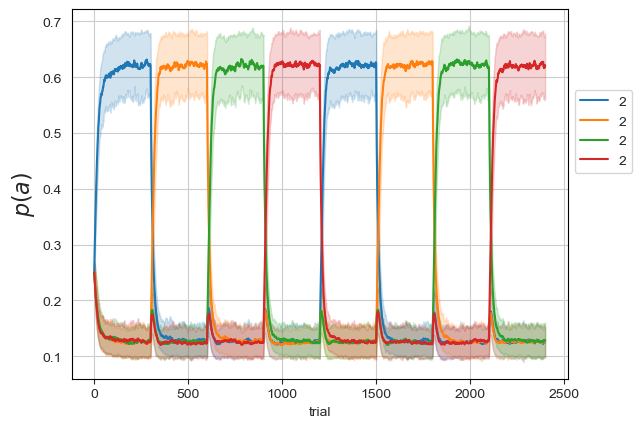

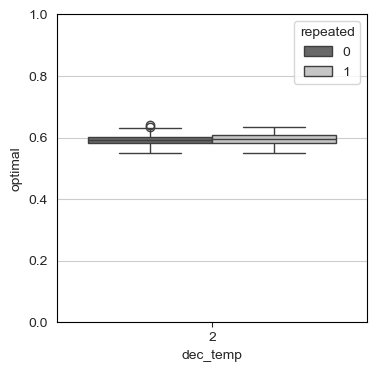

In [46]:
nb = 4
nr = 2
nc = 4

trials_per_context = 300
reps = 2
training_regime = np.tile(np.arange(nc).repeat(trials_per_context),reps)
n_trials = training_regime.size
n_sims = 200
dec_temps  = [2]
# bandit reward contingencies
p = 0.9
p_reward = np.ones([nb,nb])*(1-p) + np.eye(nb)*(p-1+p)
p_no_reward = np.ones([nb,nb])*p - np.eye(nb)*(p-1+p)
reward_contingencies = np.stack([p_no_reward, p_reward],axis=0)
# print(reward_contingencies[:,:,0])

alpha = 0.2                                       # learning rate
epsilon = 0.1                                     # e-greedy decision rule

df = simulate_MFRL(alpha, epsilon, dec_temps, training_regime, trials_per_context, n_sims, n_trials, reward_contingencies,2)
df["model"] = "MFRL"
df.to_csv("mfrl_data_long_nb42.csv",index=False)

plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"q_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$\mathbb{E}_{r|a}$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))

plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"p_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$p(a)$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))


fig, axes = plt.subplots(1,1, figsize=(4,4))
df["optimal"] = df["context"] == df["actions"]
g = sns.boxplot(data=df.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index(), y="optimal", x="dec_temp", hue="repeated",palette="Greys_r")
g.set_ylim([0,1])



### Plot template and MFRL comparison

Mann-Whitney-Wilcoxon test two-sided, P_val:1.027e-19 U_stat=9.495e+03
Mann-Whitney-Wilcoxon test two-sided, P_val:7.397e-02 U_stat=1.793e+04
Mann-Whitney-Wilcoxon test two-sided, P_val:4.026e-13 U_stat=1.161e+04


C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\2370077359.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\ntemplates"], fontsize=12)
C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\2370077359.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,1.01,0.2).round(2),fontsize=12)


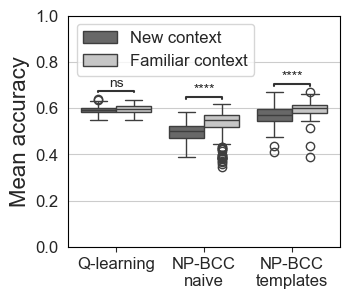

In [ ]:
mf = pd.read_csv("mfrl_data_long_nb42.csv")
mf["model"] = 0
mf["trial_n"] = mf["trial"] % 300
mf["optimal"] = mf["context"] == mf["actions"]

mf = mf.groupby(by=["agent","repeated","model"])["optimal"].mean().reset_index()

bcc_temp = pd.read_csv("new_df_habit_template_benefit_11.csv").query("fit>=0.9")
bcc_temp["optimal"] = bcc_temp["choice"] == bcc_temp["phase"]

bcc_temp["model"] = bcc_temp["template"] + 1
bcc_temp = bcc_temp.query("trial_n < 300").groupby(by=["agent","repeated","model"])["optimal"].mean().reset_index()

df = pd.concat([mf,bcc_temp])
fig, ax = plt.subplots(1,1,figsize=(3.5,3),dpi=100)
g = sns.boxplot(data=df, y="optimal", x="model", hue="repeated",palette="Greys_r")

unique_models = sorted(df["model"].unique())
box_pairs = [((model, 0), (model, 1)) for model in unique_models]
box_pairs = [((2,1), (1,1)),((2,1), (0,1)) ]

# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df, x="model", y="optimal", hue="repeated")
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", comparisons_correction=None, verbose=0)
test,results = annotator.apply_and_annotate()       

ax.set_ylim([0,1])
ax.set_ylabel("Mean accuracy", fontsize=16)
handles, labels = g.get_legend_handles_labels()
ax.legend(handles=handles,labels=["New context","Familiar context"],fontsize=12, loc="lower right")
ax.set_xlabel("")
ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\ntemplates"], fontsize=12)
ax.set_yticklabels(np.arange(0,1.01,0.2).round(2),fontsize=12)

for res in results:
	print(res.data)

### Templates figure but with structure learning removed? 

C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\1094522167.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=df.query("repeated==1"), y="optimal", x="model",palette="Greys_r")
C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\1094522167.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\ntemplates"], fontsize=12)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.865e-37 U_stat=5.213e+03
0 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:3.092e-01 U_stat=1.882e+04


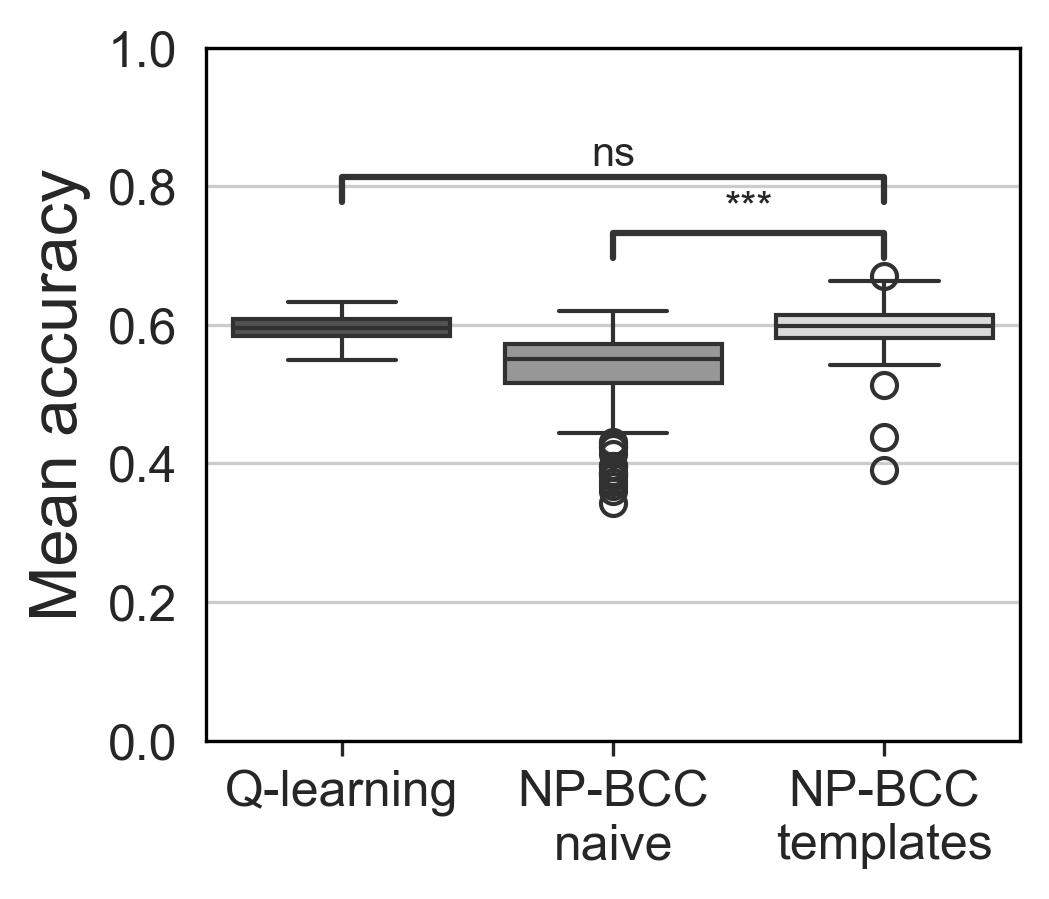

In [89]:
mf = pd.read_csv("mfrl_data_long_nb42.csv")
mf["model"] = 0
mf["trial_n"] = mf["trial"] % 300
mf["optimal"] = mf["context"] == mf["actions"]

mf = mf.groupby(by=["agent","model","repeated"])["optimal"].mean().reset_index()

bcc_temp = pd.read_csv("new_df_habit_template_benefit_11.csv")
bcc_temp["optimal"] = bcc_temp["choice"] == bcc_temp["phase"]

bcc_temp["model"] = bcc_temp["template"] + 1
bcc_temp = bcc_temp.groupby(by=["agent","model","repeated"])["optimal"].mean().reset_index()

df = pd.concat([mf,bcc_temp])
fig, ax = plt.subplots(1,1,figsize=(3.5,3),dpi=300)
g = sns.boxplot(data=df.query("repeated==1"), y="optimal", x="model",palette="Greys_r")

unique_models = sorted(df["model"].unique())
box_pairs = [(1,2),(0,2)]#[((model, 0), (model, 1)) for model in unique_models]
# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df.query("repeated==1"), x="model", y="optimal")
annotator.configure(test="Mann-Whitney", text_format="star", loc='outside', line_height=0.1, comparisons_correction=None, verbose=2 ,pvalue_thresholds=custom_thresholds)
test,results = annotator.apply_and_annotate()       

ax.set_ylim([0,1])
ax.tick_params(axis="y",labelsize=12)
ax.set_ylabel("Mean accuracy", fontsize=16)
ax.set_xlabel("")
ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\ntemplates"], fontsize=12)
# ax.set_yticklabels(np.arange(0,1.01,0.2).round(2),fontsize=12)

fig.savefig("fig8_mf_comparison.svg", bbox_inches="tight")


### Plot MF RL and automatisation comparison

C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\4229269475.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(data=df.query("repeated==1"), y="optimal", x="model", palette="Greys_r")
C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\4229269475.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=ax.yaxis.get_ticklabels(), fontsize=12)
C:\Users\siahr\AppData\Local\Temp\ipykernel_24976\4229269475.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\nautomatisation"], fontsize=13)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:4.981e-59 U_stat=2.706e+04
0 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:2.400e-07 U_stat=6.312e+04


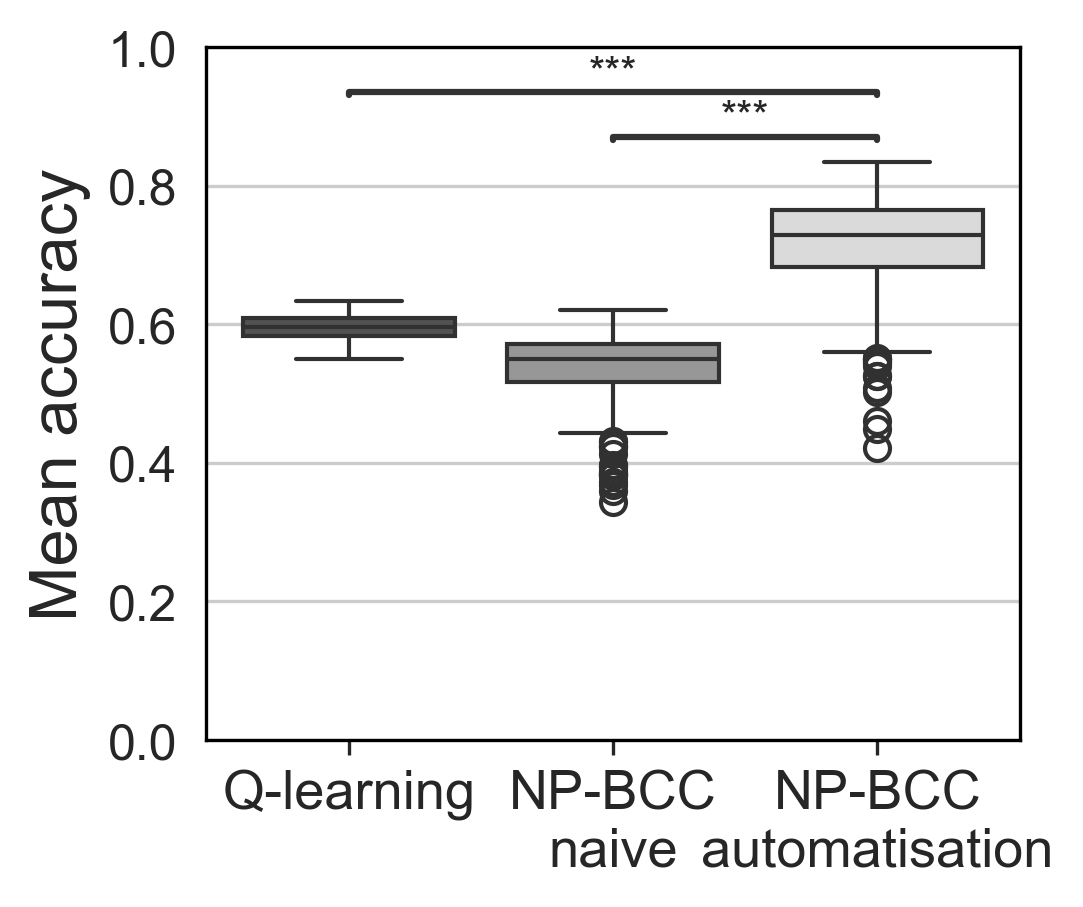

In [88]:
mf = pd.read_csv("mfrl_data_long_nb42.csv")
mf["model"] = 0
mf["trial_n"] = mf["trial"] % trials_per_context
mf["optimal"] = mf["actions"] == mf["context"]

mf = mf.query("trial_n < 300").groupby(by=["agent","repeated","model"])["optimal"].mean().reset_index()

bcc_naive = pd.read_csv("new_df_habit_template_benefit_11.csv").query("template == 0")
bcc_naive["optimal"] = bcc_naive["choice"] == bcc_naive["phase"]

bcc_naive["model"] = 1
bcc_naive = bcc_naive.query("trial_n < 300").groupby(by=["agent","repeated","model"])["optimal"].mean().reset_index()

bcc_habit = pd.read_csv("new_4_bandits_good_h70.csv")
bcc_habit["optimal"] = bcc_habit["choice"] == bcc_habit["phase"]

bcc_habit["model"] = 2
bcc_habit = bcc_habit.query("trial_n < 300").groupby(by=["agent","repeated","model"])["optimal"].mean().reset_index()

df = pd.concat([mf,bcc_naive,bcc_habit])

fig, ax = plt.subplots(1,1,figsize=(3.5,3),dpi=300)
g = sns.boxplot(data=df.query("repeated==1"), y="optimal", x="model", palette="Greys_r")

unique_models = sorted(df["model"].unique())
# box_pairs = [((model, 0), (model, 1)) for model in unique_models]
box_pairs = [(0,2), (1,2)]
# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df, x="model", y="optimal")
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", line_height=0.008, text_offset=0,comparisons_correction=None, verbose=2, pvalue_thresholds=custom_thresholds)
test,results = annotator.apply_and_annotate()       

ax.set_ylim([0,1])
ax.set_ylabel("Mean accuracy", fontsize=16)
ax.set_yticklabels(labels=ax.yaxis.get_ticklabels(), fontsize=12)
handles, labels = g.get_legend_handles_labels()
# ax.legend(handles=handles,labels=["New Context","Familiar Context"],fontsize=11, loc="upper left")
ax.set_xlabel("")
ax.set_xticklabels(labels=["Q-learning","NP-BCC\nnaive", "NP-BCC\nautomatisation"], fontsize=13)
ax.tick_params(axis="y", labelsize=12)

# ax.set_yticklabels(np.arange(0,1.01,0.2).round(2),fontsize=12)

# for res in results:
# 	print(res.data)

fig.savefig("fig7_mf_comparison.svg", bbox_inches="tight")